# L3a Advanced: Limit-Order-Book Mechanics
A quoted market is not a single price. At any instant, it is a collection of standing instructions to buy and sell at specified prices. This notebook develops a **central limit-order book** as a state that changes when traders submit, cancel, or execute orders. The organizing question is:

> If an order arrives now, what changes in the book, which orders trade, and which prices are paid?

We use a deterministic price-time-priority engine from `VLQuantitativeFinancePackage`. Prices are stored as integer ticks and quantities as whole shares, so the matching rules are exact and reproducible.

> __Learning Objectives:__
>
> By the end of this notebook, we will be able to:
>
> * __Book state:__ Define the bid book, ask book, best quotes, spread, midpoint, depth, and price-time priority.
> * __Order events:__ Distinguish passive limit orders, quote-improving limit orders, cancellations, and aggressive orders by how each changes the book.
> * __Execution cost:__ Trace a market order through several price levels, construct its fill report and volume-weighted average price, and explain why depth beyond the best quote determines the mechanical cost of a large order.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course environment and loads the `VLQuantitativeFinancePackage` matching engine, along with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), which we use to display book snapshots and fill reports. 

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Implementation
Next, we define helper functions that we use throughout the notebook. 
* The `seed_order_book(...)` function builds a small synthetic book of resting limit orders, the `book_table(...)` and `fill_table(...)` functions convert book snapshots and fill reports into [`DataFrame` instances](https://dataframes.juliadata.org/stable/), and the `plot_order_book(...)` function draws the displayed depth profile. We also set shared plot styling defaults.

Let's define these helper functions:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

function seed_order_book(; depth_scale::Int = 1)
    book = MyOrderBook(tick_size = 0.01)
    orders = [
        MyLimitOrder(1, Buy,  9_999,  60 * depth_scale; account = 101),
        MyLimitOrder(2, Buy,  9_999,  40 * depth_scale; account = 102),
        MyLimitOrder(3, Buy,  9_998, 150 * depth_scale; account = 103),
        MyLimitOrder(4, Buy,  9_997, 250 * depth_scale; account = 104),
        MyLimitOrder(5, Sell, 10_001,  80 * depth_scale; account = 201),
        MyLimitOrder(6, Sell, 10_002, 120 * depth_scale; account = 202),
        MyLimitOrder(7, Sell, 10_003, 200 * depth_scale; account = 203),
    ]
    foreach(order -> submit_order!(book, order), orders)
    return book
end

function book_table(book; levels::Int = 5)
    view = order_book_snapshot(book; levels = levels)
    bids = DataFrame(
        side = fill("BID", length(view.bids)),
        price = getfield.(view.bids, :price),
        displayed_quantity = getfield.(view.bids, :quantity),
        resting_orders = getfield.(view.bids, :order_count),
    )
    asks = DataFrame(
        side = fill("ASK", length(view.asks)),
        price = getfield.(view.asks, :price),
        displayed_quantity = getfield.(view.asks, :quantity),
        resting_orders = getfield.(view.asks, :order_count),
    )
    result = vcat(bids, asks)
    sort!(result, :price; rev = true)
    return result
end

function fill_table(book, report)
    return DataFrame(
        resting_order_id = getfield.(report.fills, :resting_order_id),
        execution_price = [ticks_to_price(book, fill.price_ticks) for fill in report.fills],
        executed_quantity = getfield.(report.fills, :quantity),
        resting_account = getfield.(report.fills, :resting_account),
    )
end

function plot_order_book(book; levels::Int = 5, title::String = "Displayed depth")
    view = order_book_snapshot(book; levels = levels)
    p = plot(; xlabel = "Displayed quantity  (bid ← 0 → ask)", ylabel = "Price (USD/share)",
        title = title, legend = :bottomright, size = (780, 410), left_margin = 4Plots.mm,
        bottom_margin = 4Plots.mm)
    for (index, level) in enumerate(view.bids)
        plot!(p, [-level.quantity, 0], [level.price, level.price];
            color = :steelblue4, linewidth = 8, label = index == 1 ? "Bid depth" : "")
    end
    for (index, level) in enumerate(view.asks)
        plot!(p, [0, level.quantity], [level.price, level.price];
            color = :darkorange2, linewidth = 8, label = index == 1 ? "Ask depth" : "")
    end
    vline!(p, [0.0]; color = :gray50, linewidth = 1, linestyle = :dash, label = "")
    return p
end

plot_order_book (generic function with 1 method)

___

## Task 1: Read the state of the book

In this task, we'll build a small synthetic order book and read off its best bid, best ask, spread, and midpoint. Those four numbers describe the state of the market at one instant, before any trade takes place.

### The book is a state, not a transaction

At event time $t$, write the displayed bid and ask books as:

$$
\mathcal{B}_t=\{(p^b_i,q^b_i)\}_{i=1}^{N_b},
\qquad
\mathcal{A}_t=\{(p^a_i,q^a_i)\}_{i=1}^{N_a},
$$

where $p$ is a price and $q$ is the displayed quantity at that price. Bid prices are ordered from highest to lowest; ask prices are ordered from lowest to highest. The top of the book is:

$$
b_t=\max_i p^b_i,
\qquad
a_t=\min_i p^a_i.
$$

The **bid-ask spread** and **midpoint** are:

$$
s_t=a_t-b_t,
\qquad
m_t=\frac{a_t+b_t}{2}.
$$

A price level may contain several individual orders. Better prices execute first. At the same price, earlier orders execute first: this is **price-time priority**. A displayed order remains an instruction, not a trade, until an aggressive order crosses the spread and matches it.

Let's seed a small synthetic book and compute these quantities:

In [3]:
book = seed_order_book();
@assert validate_order_book(book);

quote_summary = DataFrame(
    best_bid = best_quotes(book).bid,
    best_ask = best_quotes(book).ask,
    spread = bid_ask_spread(book),
    midpoint = midprice(book),
    bid_quantity = displayed_volume(book, Buy),
    ask_quantity = displayed_volume(book, Sell),
)

pretty_table(quote_summary; table_format = TextTableFormat(borders = text_table_borders__simple))
book_table(book)

=========== ========== ========= ========== ============== ===============
  best_bid   best_ask    spread   midpoint   bid_quantity   ask_quantity 
   Float64    Float64   Float64    Float64          Int64          Int64 
=========== ========== ========= ========== ============== ===============
     99.99     100.01      0.02      100.0            500            400
=========== ========== ========= ========== ============== ===============


Row,side,price,displayed_quantity,resting_orders
,String,Float64,Int64,Int64
1,ASK,100.03,200,1
2,ASK,100.02,120,1
3,ASK,100.01,80,1
4,BID,99.99,100,2
5,BID,99.98,150,1
6,BID,99.97,250,1


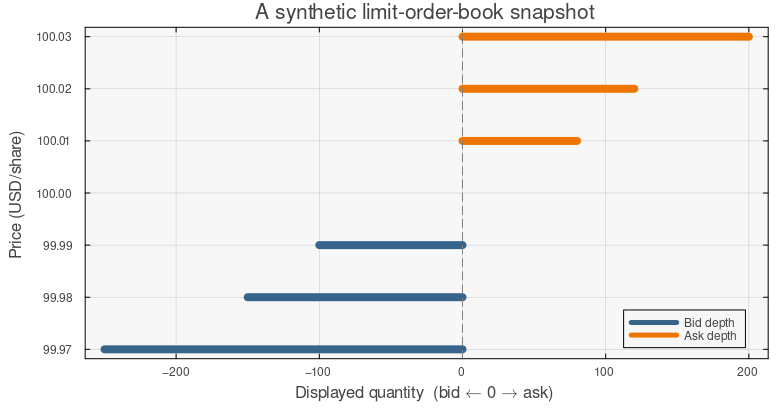

In [4]:
plot_order_book(book; title = "A synthetic limit-order-book snapshot")

The figure is a depth profile, not a transaction diagram. Bid quantity extends left from zero; ask quantity extends right. The closest two levels are the best bid and best ask. The gap between them is the spread.

The first bid level contains two separate orders (60 shares followed by 40 shares) even though the table aggregates them into 100 displayed shares. That hidden queue structure determines which resting order fills first whenever an aggressive order reaches this price; Task 3 demonstrates the allocation rule.

___

## Task 2: Change the book with passive orders

In this task, we'll add resting limit orders to the book and then cancel one, watching what each event does to the quotes. Neither event is a trade: both change the standing instructions that a later trade will meet.

### Passive orders supply displayed liquidity

An order can join the queue at the current best price or step in front of it, and those two cases look very different at the top of the book.

A buy limit order with price below the best ask does not execute immediately. It is **passive**: it joins the bid book. If it is placed at the current best bid, it adds depth behind existing orders at that price. If it is placed between the current quotes, it improves the best bid and narrows the spread.

The order is a willingness to trade subject to a price constraint; submitting it is not itself a purchase.

In [5]:
passive_book = seed_order_book()
stages = NamedTuple[]

push!(stages, (stage = "Initial book", best_bid = best_quotes(passive_book).bid,
    best_ask = best_quotes(passive_book).ask, spread = bid_ask_spread(passive_book)))

same_price_report = submit_order!(passive_book, MyLimitOrder(8, Buy, 9_999, 70; account = 105))
push!(stages, (stage = "Add 70 at best bid", best_bid = best_quotes(passive_book).bid,
    best_ask = best_quotes(passive_book).ask, spread = bid_ask_spread(passive_book)))

improving_report = submit_order!(passive_book, MyLimitOrder(9, Buy, 10_000, 50; account = 106))
push!(stages, (stage = "Add 50 inside spread", best_bid = best_quotes(passive_book).bid,
    best_ask = best_quotes(passive_book).ask, spread = bid_ask_spread(passive_book)))

@assert same_price_report.status == :resting
@assert improving_report.status == :resting
DataFrame(stages)

Row,stage,best_bid,best_ask,spread
,String,Float64,Float64,Float64
1,Initial book,99.99,100.01,0.02
2,Add 70 at best bid,99.99,100.01,0.02
3,Add 50 inside spread,100.0,100.01,0.01


In [6]:
book_table(passive_book)

Row,side,price,displayed_quantity,resting_orders
,String,Float64,Int64,Int64
1,ASK,100.03,200,1
2,ASK,100.02,120,1
3,ASK,100.01,80,1
4,BID,100.0,50,1
5,BID,99.99,170,3
6,BID,99.98,150,1
7,BID,99.97,250,1


The 70-share order increased quantity at $99.99$ but did not change the quote. The 50-share order at $100.00$ became the new best bid, reducing the spread from two cents to one cent. No execution occurred in either case.

___

### A cancellation removes an instruction

Next, we cancel a resting order and check when the quote moves. Cancelling depth away from the best price changes the liquidity available without changing the quote, so the two effects have to be told apart.

A cancellation withdraws an unexecuted resting order. Removing depth from a non-best level changes available liquidity but not the current quote. Removing the only order at the best price exposes the next price level and therefore changes the quote.

In [7]:
before_cancel = best_quotes(passive_book)
cancelled = cancel_order!(passive_book, 9)
after_cancel = best_quotes(passive_book)

cancel_summary = DataFrame(
    quantity_cancelled = cancelled.quantity,
    bid_before = before_cancel.bid,
    bid_after = after_cancel.bid,
    ask_before = before_cancel.ask,
    ask_after = after_cancel.ask,
)

@assert validate_order_book(passive_book)
cancel_summary

Row,quantity_cancelled,bid_before,bid_after,ask_before,ask_after
,Int64,Float64,Float64,Float64,Float64
1,50,100.0,99.99,100.01,100.01


The best bid reverted to $99.99$ because the quote-improving order was the only order at $100.00$. A cancellation can therefore change the publicly quoted market even though it creates no trade.

___

## Task 3: Consume the book with aggressive orders

In this task, we'll send orders that cross the spread and trade against the resting book. We follow the price a large order pays as it walks through several levels, then watch how the engine chooses between two orders sitting at the same price.

### An aggressive order consumes the opposite book

We send a market order large enough to clear more than one price level and compute the price it actually pays. That average price is worse than the ask quoted before the order arrived, and the difference is the cost of consuming depth.

A buy market order has no limit price. It first trades with the oldest order at the best ask. If its quantity exceeds that queue, it continues to the next ask. This is called **walking the book**.

For fills $(p_j,f_j)$, the volume-weighted average execution price is:

$$
\operatorname{VWAP}(Q)=\frac{1}{Q_{\mathrm{exec}}}\sum_j p_j f_j,
\qquad
Q_{\mathrm{exec}}=\sum_j f_j.
$$

VWAP is an execution statistic. It need not equal the best ask observed before the order arrived.

In [8]:
book_before_walk = seed_order_book()
book_after_walk = seed_order_book()
midpoint_before = midprice(book_after_walk)
market_report = submit_order!(book_after_walk, MyMarketOrder(Buy, 150))

execution_summary = DataFrame(
    requested_quantity = market_report.requested_quantity,
    executed_quantity = market_report.executed_quantity,
    unfilled_quantity = market_report.remaining_quantity,
    vwap = execution_vwap(market_report),
    initial_best_ask = best_quotes(book_before_walk).ask,
    midpoint_before = midpoint_before,
    midpoint_after = midprice(book_after_walk),
    implementation_shortfall = implementation_shortfall(market_report, midpoint_before),
)

@assert market_report.status == :filled
@assert validate_order_book(book_after_walk)
fill_table(book_after_walk, market_report)

Row,resting_order_id,execution_price,executed_quantity,resting_account
,Int64,Float64,Int64,Int64
1,5,100.01,80,201
2,6,100.02,70,202


In [9]:
execution_summary

Row,requested_quantity,executed_quantity,unfilled_quantity,vwap,initial_best_ask,midpoint_before,midpoint_after,implementation_shortfall
,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64
1,150,150,0,100.015,100.01,100.0,100.005,2.2


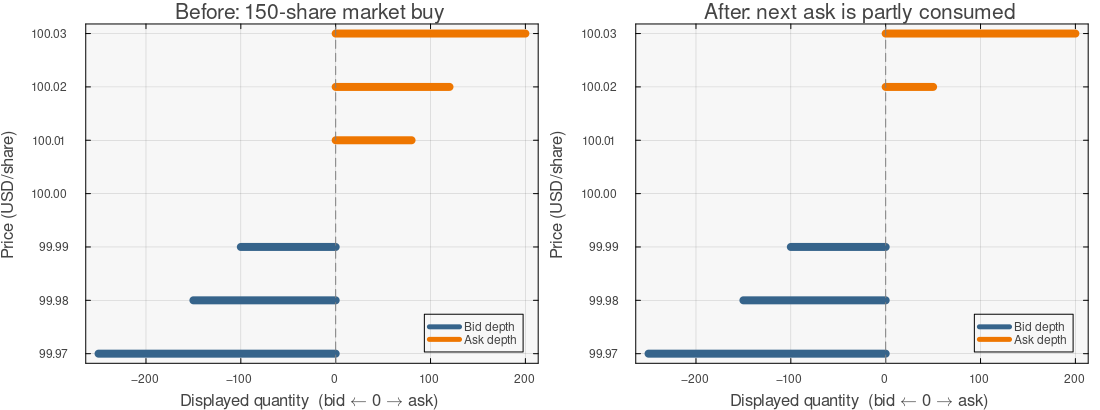

In [10]:
plot(
    plot_order_book(book_before_walk; title = "Before: 150-share market buy"),
    plot_order_book(book_after_walk; title = "After: next ask is partly consumed");
    layout = (1, 2), size = (1100, 410),
)

The order received 80 shares at $100.01$ and the remaining 70 shares at $100.02$. It exhausted the first ask level and partially consumed the second. Consequently, the best ask moved from $100.01$ to $100.02$, and the midpoint moved by half a cent because the bid did not change.

This is **mechanical impact conditional on the displayed snapshot**. It does not yet tell us whether the price change persists, whether hidden liquidity appears, or how other traders respond.

___

### Time priority operates within a price level

Finally, we rest two sell orders at the same price and send a buy order large enough to clear the first one and part of the second.

Two orders at the same price are economically equivalent in price but not in queue position. The earlier order executes first.

In [11]:
fifo_book = MyOrderBook(tick_size = 0.01)
submit_order!(fifo_book, MyLimitOrder(101, Sell, 10_001, 50; account = 1))
submit_order!(fifo_book, MyLimitOrder(102, Sell, 10_001, 70; account = 2))
fifo_report = submit_order!(fifo_book, MyMarketOrder(Buy, 80))

@assert getfield.(fifo_report.fills, :resting_order_id) == [101, 102]
@assert only(account_orders(fifo_book, 2)).quantity == 40
@assert validate_order_book(fifo_book)
fill_table(fifo_book, fifo_report)

Row,resting_order_id,execution_price,executed_quantity,resting_account
,Int64,Float64,Int64,Int64
1,101,100.01,50,1
2,102,100.01,30,2


Order 101 arrived first and was completely filled. Order 102 supplied the remaining 30 shares and retained a 40-share resting remainder. The price-level aggregate alone cannot reveal this allocation; the queue does.

___

## Summary

A limit-order book is a price-indexed collection of queued trading instructions, and every order event changes either displayed state, executed quantity, or both.

> __Key Takeaways:__
>
> * **Passive orders and cancellations reshape liquidity:** Submitting or cancelling a resting limit order can change displayed depth, and even the quoted prices, without producing a trade.
> * **Aggressive orders consume price-time-priority queues:** An order larger than top-level depth walks the book and executes at successively worse prices as it consumes deeper levels.
> * **Impact begins with state dependence:** Spread and depth set the immediate mechanical cost of an aggressive order, queue position sets fill priority among orders at the same price, and persistence requires a dynamic model.

The next notebook uses these mechanics to separate book-walking cost from linear, order-flow-imbalance, and transient market-impact models.

___